# GISAID Genomic Data Accessor - Example Notebook

This notebook demonstrates how to use the GISAID accessor to query and download
genomic surveillance data from the world's largest pathogen genomic database.

## Overview

**GISAID** (Global Initiative on Sharing All Influenza Data) provides open access to:
- 22M+ genetic sequence submissions
- 222+ countries and territories
- Multiple pathogen-specific databases (EpiCoV, EpiFlu, EpiPox, EpiRSV, EpiArbo)

**Registration**: Free account required at https://gisaid.org/register/

## Prerequisites

Install the GISAID optional dependencies:
```
pip install epidatasets[gisaid]
playwright install chromium
```

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from epidatasets.sources.gisaid import GISAIDAccessor

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

## 1. Authentication

GISAID requires a registered account.  You can provide credentials in
several ways:

1. **Interactive prompt** (default) — just call the constructor and you
   will be asked for your username (email) and password.
2. **Constructor arguments** — pass `username=` and `password=` directly.
3. **Environment variables** — set `GISAID_USERNAME` and `GISAID_PASSWORD`.
4. **Config file** — create `~/.config/epi_data/gisaid.json`:

   ```json
   {"username": "you@example.org", "password": "your_password"}
   ```

### Option A — Interactive (recommended for notebooks)

In [2]:
# This will prompt you for username and password interactively.
# GISAID usernames are email addresses.
gisaid = GISAIDAccessor(database="EpiCoV")


No GISAID credentials found in environment or config file.
Running in Jupyter — the password will be visible in the
cell output. For secure entry, use env vars or a config
file (see docstring).
Register for free at: https://gisaid.org/register/


INFO:epidatasets.sources.gisaid:Initialized GISAID accessor for EpiCoV database


### Option B — Explicit credentials

In [3]:
# gisaid = GISAIDAccessor(
#     database="EpiCoV",
#     username="you@example.org",
#     password="your_password",
# )

## 2. Explore Available Databases

In [4]:
databases = gisaid.list_databases()
databases[['database', 'description', 'pathogens']]

,database,description,pathogens
0,EpiCoV,SARS-CoV-2 / COVID-19 genomic surveillance,SARS-CoV-2 (hCoV-19)
1,EpiFlu,Influenza virus genomic surveillance,"Influenza A, B, C (all subtypes)"
2,EpiPox,Mpox virus genomic surveillance,Monkeypox virus (MPXV)
3,EpiRSV,Respiratory Syncytial Virus surveillance,RSV A and B subgroups
4,EpiArbo,Arbovirus genomic surveillance (early access),"Dengue (DENV), Zika (ZIKV), Chikungunya (CHIKV..."


## 3. Geographic Coverage

GISAID covers 222+ countries grouped into 6 regions.

Total countries: 217


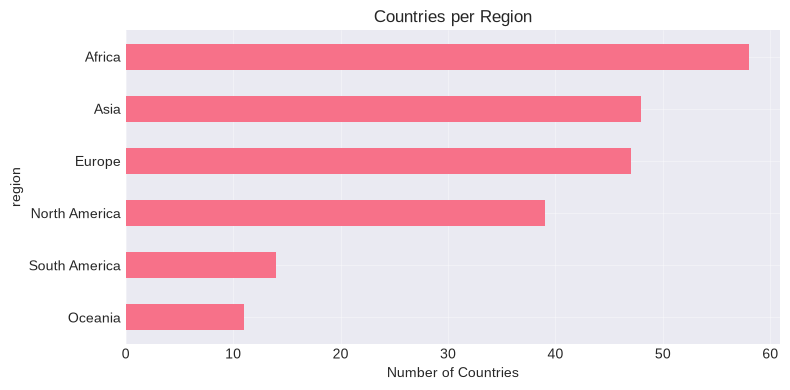

In [5]:
countries = gisaid.list_countries()
print(f"Total countries: {len(countries)}")

countries.groupby('region').size().sort_values(
    ascending=True
).plot(kind='barh', figsize=(8, 4), title='Countries per Region')
plt.xlabel('Number of Countries')
plt.tight_layout()
plt.show()

## 4. Query COVID-19 Data

Search for SARS-CoV-2 sequences with filters.

The first query opens a headless browser, logs into GISAID, and
retrieves results via GISAID's JavaScript framework.  Results are
cached for subsequent calls.

In [6]:
df = gisaid.query(
    location="Brazil",
    lineage="JN.1",
    from_date="2024-01-01",
    to_date="2024-06-30",
    complete=True,
    nrows=50,
)

print(f"Found {len(df)} records")
df.head()

INFO:epidatasets.sources.gisaid:Logging into GISAID...
INFO:epidatasets.sources.gisaid:Session: SID=9BB7F0Z0ISW7... WID=wid_tjazvg_2ys6 PID=pid_tjazvg_2ys7


RuntimeError: GISAID login failed: Username or password wrong!. Please verify your username and password. GISAID usernames are typically email addresses.

## 5. Download Metadata

In [ ]:
if not df.empty and 'accession_id' in df.columns:
    metadata = gisaid.download_metadata(
        list_of_accession_ids=df['accession_id'].head(10).tolist(),
        metadata_type="dates_and_location",
    )
    print(f"Downloaded metadata for {len(metadata)} records")
    metadata.head()

## 6. Download Sequences (FASTA)

In [ ]:
if not df.empty and 'accession_id' in df.columns:
    fasta = gisaid.download_sequences(
        list_of_accession_ids=df['accession_id'].head(5).tolist(),
    )
    lines = fasta.split('\n')
    print(f"FASTA: {len(lines)} lines")
    print('\\n'.join(lines[:6]))

## 7. Using Different Databases

Switch between GISAID databases by creating a new accessor.

In [ ]:
# Influenza data
flu = GISAIDAccessor(database="EpiFlu")  # will prompt for credentials
flu_df = flu.query(location="Brazil", nrows=20)
print(f"Influenza records: {len(flu_df)}")
flu.close()

## 8. Clean Up

Always close the browser when done.

In [ ]:
gisaid.close()
print("Done!")